In [18]:
# =========================
# IMPORTS
# =========================

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer

# =========================
# LOAD CLINICAL DATA
# =========================

clinical_full = pd.read_csv("ADSL.csv")

print("Clinical raw shape:", clinical_full.shape)

print("\nDX distribution:")
print(clinical_full["DX"].value_counts(dropna=False))

# =========================
# CREATE LABELS
# =========================

clinical_full = clinical_full[
    clinical_full["DX"].isin(["CN", "DEM"])
].copy()

clinical_full["LABEL"] = clinical_full["DX"].map({
    "CN": 0,
    "DEM": 1
})

print("\nLabel counts:")
print(clinical_full["LABEL"].value_counts())

# =========================
# BUILD CLINICAL DATASET
# =========================

clinical = clinical_full[[
    "SUBJID",
    "AGE",
    "SEX",
    "EDUC",
    "MMSCORE",
    "MOCA",
    "CDRSB",
    "FAQTOTAL",
    "RAVLTFG",
    "RAVLTIMM",
    "TRABSCOR",
    "LABEL"
]].copy()

# =========================
# CLEAN CLINICAL DATA
# =========================

clinical = clinical.rename(columns={
    "SUBJID": "RID"
})

clinical["SEX"] = clinical["SEX"].map({
    "Male": 0,
    "Female": 1
})

clinical = clinical.dropna()

clinical = clinical.drop_duplicates(
    subset="RID"
)

print("\nClinical cleaned shape:", clinical.shape)

# =========================
# LOAD MRI DATA
# =========================

mri = pd.read_csv("UCSFFSX6.csv")

print("\nMRI raw shape:", mri.shape)

# =========================
# KEEP LATEST MRI SCAN
# =========================

mri["EXAMDATE"] = pd.to_datetime(
    mri["EXAMDATE"]
)

mri = mri.sort_values("EXAMDATE")

mri = mri.drop_duplicates(
    subset="RID",
    keep="last"
)

print("\nMRI deduplicated shape:", mri.shape)

# =========================
# MRI FEATURE FILTERING
# =========================

numeric_cols = mri.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

drop_cols = ["RID", "IMAGEUID"]

mri_features = [
    c for c in numeric_cols
    if c not in drop_cols
]

# =========================
# REMOVE HIGH-MISSING FEATURES
# =========================

missing_pct = mri[mri_features].isnull().mean()

good_features = missing_pct[
    missing_pct < 0.3
].index.tolist()

mri = mri[["RID"] + good_features]

print("\nMRI feature count after filtering:", len(good_features))

# =========================
# MERGE
# =========================

merged = pd.merge(
    clinical,
    mri,
    on="RID",
    how="inner"
)

print("\nMerged shape BEFORE imputation:", merged.shape)

# =========================
# IMPUTATION
# =========================

feature_cols = [
    c for c in merged.columns
    if c not in ["RID", "LABEL"]
]

imputer = SimpleImputer(
    strategy="median"
)

merged[feature_cols] = imputer.fit_transform(
    merged[feature_cols]
)

# =========================
# TOP MRI FEATURES
# =========================

mri_features = [
    c for c in merged.columns
    if c.startswith("ST")
]

mri_variance = merged[mri_features].var()

top_mri_features = (
    mri_variance
    .sort_values(ascending=False)
    .head(30)
    .index
    .tolist()
)

print("\nTop MRI features:")
print(top_mri_features)

# =========================
# FINAL FEATURES
# =========================

clinical_features = [
    "AGE",
    "SEX",
    "EDUC",
    "RAVLTFG",
    "RAVLTIMM",
    "TRABSCOR"
]

final_features = (
    clinical_features
    + top_mri_features
)

# =========================
# BUILD X/y
# =========================

X = merged[final_features]

y = merged["LABEL"]

# =========================
# FINAL DIAGNOSTICS
# =========================

print("\n===== FINAL DATASET =====")

print("Shape:", merged.shape)

print("\nLabel distribution:")
print(y.value_counts())

print("\nMissing values:")
print(merged.isnull().sum().sum())

print("\nDuplicate RIDs:")
print(merged["RID"].duplicated().sum())

Clinical raw shape: (5146, 55)

DX distribution:
DX
NaN    2116
MCI    1338
CN     1215
DEM     477
Name: count, dtype: int64

Label counts:
LABEL
0    1215
1     477
Name: count, dtype: int64

Clinical cleaned shape: (772, 12)

MRI raw shape: (2270, 347)

MRI deduplicated shape: (1130, 347)

MRI feature count after filtering: 323

Merged shape BEFORE imputation: (412, 335)

Top MRI features:
['ST10CV', 'ST155SV', 'ST154SV', 'ST152SV', 'ST149SV', 'ST150SV', 'ST151SV', 'ST147SV', 'ST148SV', 'ST37SV', 'ST96SV', 'ST87sa', 'ST28SA', 'ST76SV', 'ST17SV', 'ST128SV', 'ST153SV', 'ST1SV', 'ST115CV', 'ST56CV', 'ST18SV', 'ST77SV', 'ST114CV', 'ST55CV', 'ST90CV', 'ST32CV', 'ST31CV', 'ST57CV', 'ST116CV', 'ST91CV']

===== FINAL DATASET =====
Shape: (412, 335)

Label distribution:
LABEL
0    351
1     61
Name: count, dtype: int64

Missing values:
0

Duplicate RIDs:
0


In [19]:
# =========================
# TRAIN / TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain labels:")
print(y_train.value_counts())

print("\nTest labels:")
print(y_test.value_counts())

# =========================
# SCALE FEATURES
# =========================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# =========================
# IMPORT MODELS
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    roc_auc_score,
    classification_report
)

# =========================
# DEFINE MODELS
# =========================

models = {

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    )
}

# =========================
# MODEL COMPARISON
# =========================

results = []

for name, model in models.items():

    print(f"\n===== TRAINING {name} =====")

    model.fit(X_train_scaled, y_train)

    probs = model.predict_proba(
        X_test_scaled
    )[:, 1]

    preds = model.predict(
        X_test_scaled
    )

    auc = roc_auc_score(
        y_test,
        probs
    )

    results.append({
        "Model": name,
        "AUC": auc
    })

    print("AUC:", auc)

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        preds
    ))

# =========================
# RESULTS DATAFRAME
# =========================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="AUC",
    ascending=False
)

print("\n===== MODEL COMPARISON =====")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

print("\nBest Model:", best_model_name)

Train shape: (329, 36)
Test shape: (83, 36)

Train labels:
LABEL
0    280
1     49
Name: count, dtype: int64

Test labels:
LABEL
0    71
1    12
Name: count, dtype: int64

===== TRAINING Logistic Regression =====
AUC: 0.9765258215962441

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        71
           1       0.79      0.92      0.85        12

    accuracy                           0.95        83
   macro avg       0.89      0.94      0.91        83
weighted avg       0.96      0.95      0.95        83


===== TRAINING Random Forest =====
AUC: 0.942488262910798

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.89      0.67      0.76        12

    accuracy                           0.94        83
   macro avg       0.92      0.83      0.86        83
weighted avg       0.94      0.94      0.94        83


=

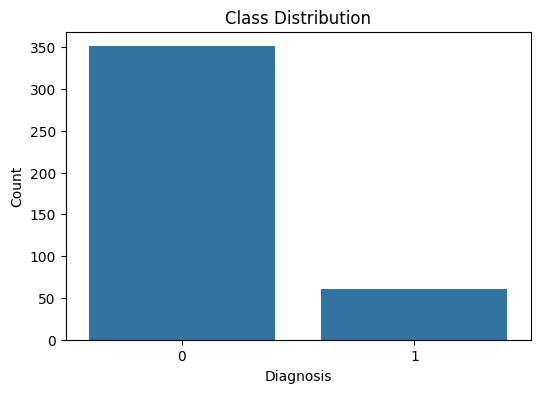

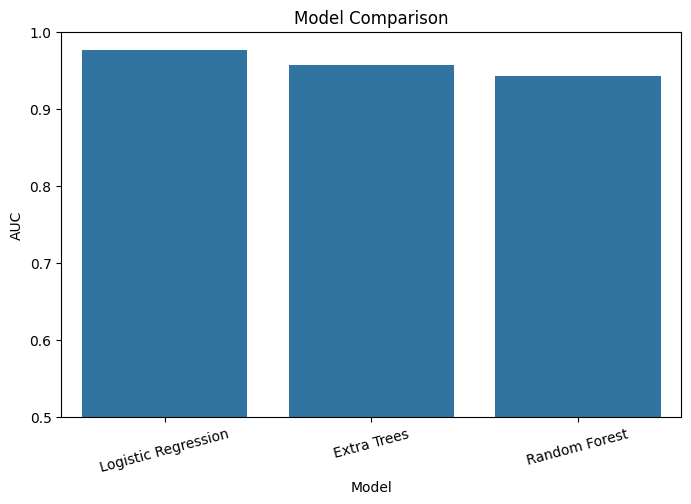

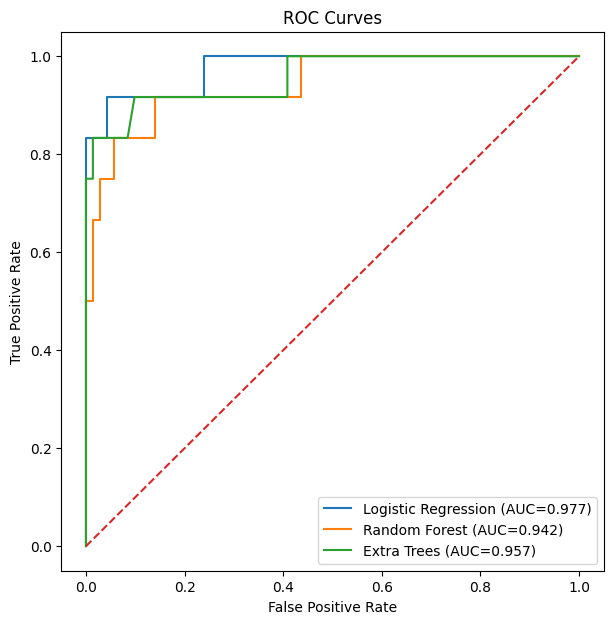

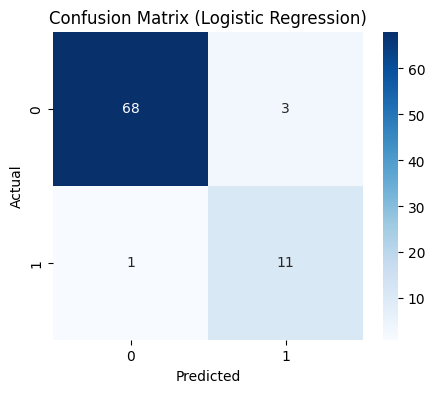

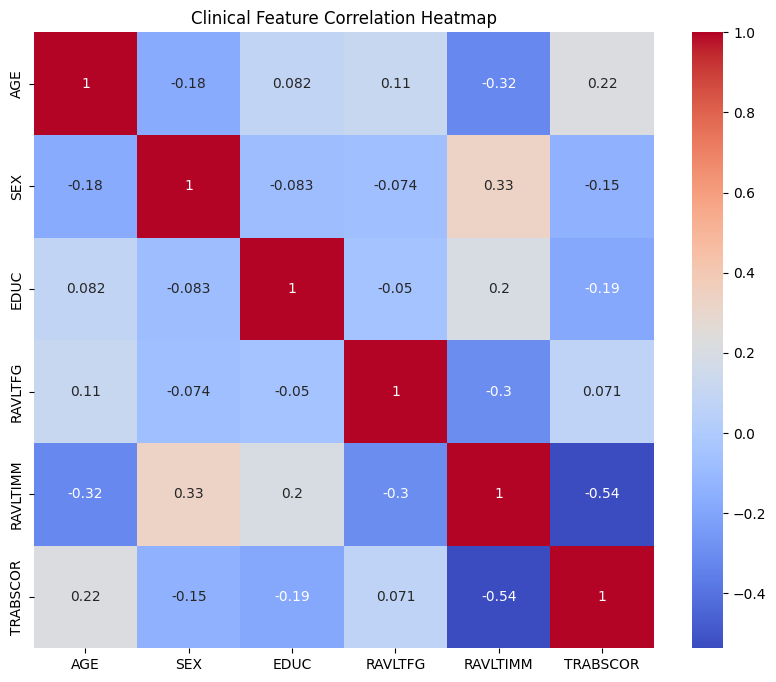

In [20]:
# =========================
# CLASS DISTRIBUTION
# =========================

plt.figure(figsize=(6,4))

sns.countplot(
    x=y
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()


# =========================
# MODEL COMPARISON BARPLOT
# =========================

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="AUC"
)

plt.title("Model Comparison")

plt.ylim(0.5, 1.0)

plt.xticks(rotation=15)

plt.show()


# =========================
# ROC CURVES FOR ALL MODELS
# =========================

from sklearn.metrics import roc_curve

plt.figure(figsize=(7,7))

for name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    probs = model.predict_proba(
        X_test_scaled
    )[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probs
    )

    auc = roc_auc_score(
        y_test,
        probs
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.show()


# =========================
# CONFUSION MATRIX
# =========================

from sklearn.metrics import confusion_matrix

best_model.fit(
    X_train_scaled,
    y_train
)

best_preds = best_model.predict(
    X_test_scaled
)

cm = confusion_matrix(
    y_test,
    best_preds
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix ({best_model_name})")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# =========================
# FEATURE IMPORTANCE
# =========================

if hasattr(best_model, "feature_importances_"):

    importance_df = pd.DataFrame({
        "Feature": final_features,
        "Importance": best_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    print("\n===== TOP FEATURES =====")
    print(importance_df.head(20))

    top_features = importance_df.head(15)

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=top_features,
        x="Importance",
        y="Feature"
    )

    plt.title("Top Feature Importances")

    plt.show()


# =========================
# CLINICAL CORRELATION HEATMAP
# =========================

plt.figure(figsize=(10,8))

sns.heatmap(
    merged[clinical_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Clinical Feature Correlation Heatmap")

plt.show()

In [21]:
# =====================================================
# MISSING CLINICAL MODALITY EXPERIMENT
# =====================================================

# Create copy of test data
X_test_missing = X_test.copy()

# Remove clinical modality
X_test_missing[clinical_features] = 0

# Scale using SAME scaler
X_test_missing_scaled = scaler.transform(
    X_test_missing
)

# Predict
missing_probs = best_model.predict_proba(
    X_test_missing_scaled
)[:,1]

# Evaluate
from sklearn.metrics import roc_auc_score

missing_auc = roc_auc_score(
    y_test,
    missing_probs
)

print("Baseline AUC:")
print(results_df.iloc[0]["AUC"])

print("\nAUC with missing clinical modality:")
print(missing_auc)

print("\nPerformance Drop:")
print(
    results_df.iloc[0]["AUC"] - missing_auc
)

Baseline AUC:
0.9765258215962441

AUC with missing clinical modality:
0.7711267605633803

Performance Drop:
0.20539906103286387


In [22]:
# =====================================================
# ROBUSTNESS TRAINING
# RANDOM CLINICAL MODALITY DROPOUT
# =====================================================

import numpy as np

# Copy training data
X_train_robust = X_train.copy()

# Randomly choose rows
mask = np.random.rand(
    len(X_train_robust)
) < 0.3

# Remove clinical modality
X_train_robust.loc[
    mask,
    clinical_features
] = 0

print("Rows with dropped clinical modality:")
print(mask.sum())

# =====================================================
# SCALE
# =====================================================

from sklearn.preprocessing import StandardScaler

robust_scaler = StandardScaler()

X_train_robust_scaled = robust_scaler.fit_transform(
    X_train_robust
)

X_test_scaled_robust = robust_scaler.transform(
    X_test
)

X_test_missing_scaled_robust = robust_scaler.transform(
    X_test_missing
)

# =====================================================
# TRAIN ROBUST MODEL
# =====================================================

from sklearn.linear_model import LogisticRegression

robust_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

robust_model.fit(
    X_train_robust_scaled,
    y_train
)

# =====================================================
# EVALUATE FULL TEST DATA
# =====================================================

robust_full_probs = robust_model.predict_proba(
    X_test_scaled_robust
)[:,1]

robust_full_auc = roc_auc_score(
    y_test,
    robust_full_probs
)

# =====================================================
# EVALUATE MISSING MODALITY TEST DATA
# =====================================================

robust_missing_probs = robust_model.predict_proba(
    X_test_missing_scaled_robust
)[:,1]

robust_missing_auc = roc_auc_score(
    y_test,
    robust_missing_probs
)

# =====================================================
# RESULTS
# =====================================================

print("\n===== ROBUSTNESS RESULTS =====")

print("\nOriginal Full AUC:")
print(results_df.iloc[0]["AUC"])

print("\nOriginal Missing-Modality AUC:")
print(missing_auc)

print("\nRobust Model Full AUC:")
print(robust_full_auc)

print("\nRobust Model Missing-Modality AUC:")
print(robust_missing_auc)

print("\nOriginal Performance Drop:")
print(
    results_df.iloc[0]["AUC"] - missing_auc
)

print("\nRobust Performance Drop:")
print(
    robust_full_auc - robust_missing_auc
)

Rows with dropped clinical modality:
98

===== ROBUSTNESS RESULTS =====

Original Full AUC:
0.9765258215962441

Original Missing-Modality AUC:
0.7711267605633803

Robust Model Full AUC:
0.9800469483568075

Robust Model Missing-Modality AUC:
0.8661971830985916

Original Performance Drop:
0.20539906103286387

Robust Performance Drop:
0.11384976525821588
